# Error Analysis for Bengali Coreference Resolution

This notebook performs detailed error analysis on your best model (MuRIL-Large, Experiment 6).

**Prerequisites:**
- Run this after `bencoref_only_final.ipynb` has completed

**Outputs:**
1. Error breakdown by mention type (pronoun vs noun phrase)
2. Distance analysis (same sentence vs far apart)
3. Concrete examples for thesis
4. LaTeX table ready to use

## Cell 1: Imports and Configuration

In [1]:
import json
import numpy as np
import torch
import re
from collections import defaultdict
from pathlib import Path
from typing import List, Dict, Tuple
from tqdm import tqdm
import networkx as nx
from transformers import AutoModel, AutoTokenizer
import torch.nn as nn

# Device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

# =============================================================================
# PATHS - MATCHING YOUR bencoref_only_final.ipynb
# =============================================================================
BASE_DIR = Path('/teamspace/studios/this_studio/final_experiments')

# Data files
TRAIN_FILE = BASE_DIR / 'bencoref_only.conll'
DEV_FILE = BASE_DIR / 'dev.conll'
TEST_FILE = BASE_DIR / 'test.conll'

# Output from Experiment 6
OUTPUT_DIR = BASE_DIR / 'experiment_6_bencoref_only'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'

# Error analysis output
ERROR_OUTPUT_DIR = OUTPUT_DIR / 'error_analysis'
ERROR_OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Test file: {TEST_FILE}")
print(f"Checkpoint directory: {CHECKPOINT_DIR}")
print(f"Error output directory: {ERROR_OUTPUT_DIR}")

# Verify paths exist
assert TEST_FILE.exists(), f"Test file not found: {TEST_FILE}"
assert CHECKPOINT_DIR.exists(), f"Checkpoint directory not found: {CHECKPOINT_DIR}"
print("\n✓ All paths verified!")

Device: cpu
Base directory: /teamspace/studios/this_studio/final_experiments
Test file: /teamspace/studios/this_studio/final_experiments/test.conll
Checkpoint directory: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/checkpoints
Error output directory: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/error_analysis

✓ All paths verified!


## Cell 2: Find Best Model Checkpoint and Threshold

In [2]:
# List available checkpoints
print("Available checkpoints:")
for f in CHECKPOINT_DIR.glob("*.pt"):
    print(f"  {f.name}")

# Load results to get threshold
results_file = OUTPUT_DIR / 'exp6_bencoref_only_results.json'
if results_file.exists():
    with open(results_file) as f:
        saved_results = json.load(f)
    
    print("\nSaved results:")
    for r in saved_results['results']:
        print(f"  {r['model_name']}: F1={r['test_conll_f1']:.2%}, threshold={r['best_threshold']}")
    
    # Find MuRIL-Large
    muril_result = [r for r in saved_results['results'] if 'MuRIL' in r['model_name']][0]
    BEST_THRESHOLD = muril_result['best_threshold']
    print(f"\n✓ MuRIL-Large threshold: {BEST_THRESHOLD}")
else:
    print(f"Results file not found: {results_file}")
    print("Please set BEST_THRESHOLD manually:")
    BEST_THRESHOLD = 0.70  # <-- UPDATE THIS MANUALLY IF NEEDED
    print(f"Using default threshold: {BEST_THRESHOLD}")

Available checkpoints:
  BERT_Base_Uncased_mlp.pt
  BanglaBERT_Base_mlp.pt
  MuRIL_Large_mlp.pt
  RemBERT_mlp.pt
  mBERT_mlp.pt

Saved results:
  mBERT: F1=6415.44%, threshold=0.7500000000000002
  BanglaBERT-Base: F1=6339.09%, threshold=0.6500000000000001
  RemBERT: F1=6388.14%, threshold=0.8500000000000002
  MuRIL-Large: F1=6672.62%, threshold=0.7000000000000002
  BERT-Base-Uncased: F1=6363.82%, threshold=0.45000000000000007

✓ MuRIL-Large threshold: 0.7000000000000002


## Cell 3: Bengali Linguistic Patterns

In [3]:
# Bengali pronouns for error categorization
BENGALI_PRONOUNS = {
    # Personal pronouns
    'আমি', 'আমরা', 'তুমি', 'তোমরা', 'আপনি', 'আপনারা',
    'সে', 'তিনি', 'তারা', 'তাঁরা', 'ও', 'এরা', 'ওরা',
    # Possessive forms
    'আমার', 'আমাদের', 'তোমার', 'তোমাদের', 'আপনার', 'আপনাদের',
    'তার', 'তাঁর', 'তাদের', 'তাঁদের', 'ওর', 'ওদের',
    # Accusative/Dative forms
    'আমাকে', 'তোমাকে', 'আপনাকে', 'তাকে', 'তাঁকে', 'ওকে',
    # Demonstratives
    'এই', 'এটা', 'এটি', 'সেই', 'সেটা', 'সেটি', 'ওই', 'ওটা',
    'এ', 'ও', 'সে',
    # Reflexives
    'নিজে', 'নিজের', 'নিজেকে',
    # Relative pronouns
    'যে', 'যিনি', 'যারা', 'যা', 'যাঁরা',
    # Others
    'ইনি', 'উনি', 'এঁরা', 'ওঁরা', 'তাহাকে', 'ইহা', 'উহা', 'তাহারা', 'ইহারা'
}

def is_pronoun(text):
    """Check if mention text is a pronoun."""
    text_clean = text.strip()
    if text_clean in BENGALI_PRONOUNS:
        return True
    words = text_clean.split()
    if len(words) == 1 and words[0] in BENGALI_PRONOUNS:
        return True
    return False

print(f"✓ Loaded {len(BENGALI_PRONOUNS)} Bengali pronouns")

✓ Loaded 57 Bengali pronouns


## Cell 4: Data Parser

In [4]:
def parse_conll_file(filepath: Path) -> List[Dict]:
    """Parse CoNLL-2012 format file and extract documents with mentions and clusters."""
    documents = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()
    
    doc_pattern = r'#begin document \((.+?)\).*?\n(.*?)#end document'
    doc_matches = re.findall(doc_pattern, content, re.DOTALL)
    
    for doc_id, doc_content in doc_matches:
        sentences = []
        current_sentence = []
        
        cluster_mentions = defaultdict(list)
        open_mentions = defaultdict(list)
        
        word_idx_in_sent = 0
        sent_idx = 0
        
        for line in doc_content.strip().split('\n'):
            if not line.strip():
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
                    sent_idx += 1
                    word_idx_in_sent = 0
                continue
            
            parts = line.split()
            if len(parts) < 4:
                continue
            
            token = parts[3]
            coref_col = parts[-1]
            
            current_sentence.append(token)
            
            if coref_col != '-' and coref_col != '_':
                annotations = coref_col.split('|')
                for ann in annotations:
                    single_match = re.match(r'^\((\d+)\)$', ann)
                    if single_match:
                        cluster_id = int(single_match.group(1))
                        cluster_mentions[cluster_id].append(
                            (sent_idx, word_idx_in_sent, word_idx_in_sent)
                        )
                        continue
                    
                    open_match = re.match(r'^\((\d+)$', ann)
                    if open_match:
                        cluster_id = int(open_match.group(1))
                        open_mentions[cluster_id].append((sent_idx, word_idx_in_sent))
                        continue
                    
                    close_match = re.match(r'^(\d+)\)$', ann)
                    if close_match:
                        cluster_id = int(close_match.group(1))
                        if open_mentions[cluster_id]:
                            start_sent, start_word = open_mentions[cluster_id].pop()
                            if start_sent == sent_idx:
                                cluster_mentions[cluster_id].append(
                                    (sent_idx, start_word, word_idx_in_sent)
                                )
            
            word_idx_in_sent += 1
        
        if current_sentence:
            sentences.append(current_sentence)
        
        # Convert to mention list and cluster indices
        all_mentions = []
        mention_to_idx = {}
        clusters = []
        
        for cluster_id, mention_spans in cluster_mentions.items():
            cluster_indices = []
            for s_idx, start, end in mention_spans:
                key = (s_idx, start, end)
                if key not in mention_to_idx:
                    mention_to_idx[key] = len(all_mentions)
                    all_mentions.append({
                        'sentence_idx': s_idx,
                        'start': start,
                        'end': end
                    })
                cluster_indices.append(mention_to_idx[key])
            if cluster_indices:
                clusters.append(cluster_indices)
        
        if all_mentions:
            documents.append({
                'id': doc_id,
                'sentences': sentences,
                'mentions': all_mentions,
                'clusters': clusters
            })
    
    return documents

# Load test data
print("Loading test data...")
test_docs = parse_conll_file(TEST_FILE)
print(f"✓ Loaded {len(test_docs)} test documents")
print(f"  Total mentions: {sum(len(d['mentions']) for d in test_docs)}")
print(f"  Total clusters: {sum(len(d['clusters']) for d in test_docs)}")

Loading test data...
✓ Loaded 71 test documents
  Total mentions: 3308
  Total clusters: 282


## Cell 5: Model and Clustering Definitions

In [5]:
def graph_connected_components(similarity_matrix: np.ndarray, threshold: float) -> List[List[int]]:
    """Graph-based Connected Components clustering."""
    n_mentions = similarity_matrix.shape[0]
    if n_mentions == 0:
        return []
    if n_mentions == 1:
        return [[0]]
    
    G = nx.Graph()
    G.add_nodes_from(range(n_mentions))
    
    for i in range(n_mentions):
        for j in range(i + 1, n_mentions):
            if similarity_matrix[i, j] >= threshold:
                G.add_edge(i, j)
    
    clusters = [list(component) for component in nx.connected_components(G)]
    return clusters


class PairwiseCorefScorer(nn.Module):
    """Frozen Encoder + Trainable Pairwise Classifier."""
    
    def __init__(self, encoder, tokenizer, hidden_dim: int, 
                 mlp_hidden: int = 512, dropout: float = 0.3, device='cuda'):
        super().__init__()
        self.encoder = encoder
        self.tokenizer = tokenizer
        self.device = device
        self.hidden_dim = hidden_dim
        
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.encoder.eval()
        
        span_dim = hidden_dim * 3
        pair_dim = span_dim * 4
        
        self.pairwise_mlp = nn.Sequential(
            nn.Linear(pair_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, mlp_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden // 2, 1),
            nn.Sigmoid()
        )
        
        self.pairwise_mlp = self.pairwise_mlp.to(device)
    
    def get_span_embedding(self, sentence: List[str], start: int, end: int) -> torch.Tensor:
        encoding = self.tokenizer(
            sentence,
            is_split_into_words=True,
            return_tensors='pt',
            truncation=True,
            max_length=512,
            padding=True
        )
        encoding = {k: v.to(self.device) for k, v in encoding.items()}
        
        word_ids = self.tokenizer(
            sentence,
            is_split_into_words=True,
            truncation=True,
            max_length=512
        ).word_ids()
        
        positions = []
        for tok_idx, word_idx in enumerate(word_ids):
            if word_idx is not None and start <= word_idx <= end:
                positions.append(tok_idx)
        
        if not positions:
            positions = [1]
        
        with torch.no_grad():
            outputs = self.encoder(**encoding)
            hidden = outputs.last_hidden_state[0]
        
        start_emb = hidden[positions[0]]
        end_emb = hidden[positions[-1]]
        mean_emb = hidden[positions].mean(dim=0)
        
        return torch.cat([start_emb, end_emb, mean_emb])
    
    def get_all_mention_embeddings(self, doc: Dict) -> torch.Tensor:
        embeddings = []
        for mention in doc['mentions']:
            sent_idx = mention['sentence_idx']
            sentence = doc['sentences'][sent_idx]
            emb = self.get_span_embedding(sentence, mention['start'], mention['end'])
            embeddings.append(emb)
        return torch.stack(embeddings)
    
    def compute_pairwise_scores(self, embeddings: torch.Tensor) -> np.ndarray:
        n = embeddings.shape[0]
        scores = np.zeros((n, n))
        
        self.pairwise_mlp.eval()
        with torch.no_grad():
            for i in range(n):
                for j in range(i + 1, n):
                    emb_i = embeddings[i]
                    emb_j = embeddings[j]
                    
                    pair_features = torch.cat([
                        emb_i, emb_j,
                        emb_i * emb_j,
                        torch.abs(emb_i - emb_j)
                    ]).unsqueeze(0)
                    
                    score = self.pairwise_mlp(pair_features).item()
                    scores[i, j] = score
                    scores[j, i] = score
        
        return scores

print("✓ Model and clustering functions defined")

✓ Model and clustering functions defined


## Cell 6: Load Best Model (MuRIL-Large)

In [6]:
# Model configuration
MODEL_NAME = "google/muril-large-cased"
HIDDEN_DIM = 1024

# Find checkpoint file
checkpoint_files = list(CHECKPOINT_DIR.glob("*MuRIL*")) + list(CHECKPOINT_DIR.glob("*muril*"))
if checkpoint_files:
    CHECKPOINT_PATH = checkpoint_files[0]
    print(f"Found checkpoint: {CHECKPOINT_PATH}")
else:
    # Try common naming patterns
    possible_names = [
        "MuRIL-Large_best.pt",
        "muril_large_best.pt", 
        "MuRIL_Large_best.pt",
        "best_MuRIL-Large.pt"
    ]
    for name in possible_names:
        if (CHECKPOINT_DIR / name).exists():
            CHECKPOINT_PATH = CHECKPOINT_DIR / name
            break
    else:
        print("Available files in checkpoint dir:")
        for f in CHECKPOINT_DIR.glob("*"):
            print(f"  {f.name}")
        raise FileNotFoundError("Could not find MuRIL checkpoint. Please set CHECKPOINT_PATH manually.")

print(f"\nLoading {MODEL_NAME}...")
encoder = AutoModel.from_pretrained(MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder = encoder.to(DEVICE)

model = PairwiseCorefScorer(
    encoder=encoder,
    tokenizer=tokenizer,
    hidden_dim=HIDDEN_DIM,
    device=DEVICE
)

# Load trained weights
print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.pairwise_mlp.load_state_dict(checkpoint)
model.pairwise_mlp.eval()

print(f"\n✓ Model loaded successfully!")
print(f"  Model: MuRIL-Large")
print(f"  Threshold: {BEST_THRESHOLD}")

Found checkpoint: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/checkpoints/MuRIL_Large_mlp.pt

Loading google/muril-large-cased...


/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /system/conda/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializin

Loading checkpoint from /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/checkpoints/MuRIL_Large_mlp.pt...

✓ Model loaded successfully!
  Model: MuRIL-Large
  Threshold: 0.7000000000000002


## Cell 7: Error Analysis Functions

In [7]:
def get_mention_text(doc, mention_idx):
    """Extract mention text from document."""
    mention = doc['mentions'][mention_idx]
    sent_idx = mention['sentence_idx']
    start = mention['start']
    end = mention['end']
    tokens = doc['sentences'][sent_idx][start:end+1]
    return ' '.join(tokens)


def analyze_document_errors(doc, pred_clusters):
    """Analyze errors for a single document."""
    gold_clusters = doc['clusters']
    mentions = doc['mentions']
    
    # Build mappings
    gold_map = {}
    for c_idx, cluster in enumerate(gold_clusters):
        for m in cluster:
            gold_map[m] = c_idx
    
    pred_map = {}
    for c_idx, cluster in enumerate(pred_clusters):
        for m in cluster:
            pred_map[m] = c_idx
    
    errors = {'false_positives': [], 'false_negatives': []}
    
    # False negatives: pairs that should be linked but aren't
    for cluster in gold_clusters:
        for i, m1 in enumerate(cluster):
            for m2 in cluster[i+1:]:
                if pred_map.get(m1) != pred_map.get(m2):
                    t1 = get_mention_text(doc, m1)
                    t2 = get_mention_text(doc, m2)
                    errors['false_negatives'].append({
                        'm1_idx': m1, 'm2_idx': m2,
                        'm1_text': t1, 'm2_text': t2,
                        'm1_sent': mentions[m1]['sentence_idx'],
                        'm2_sent': mentions[m2]['sentence_idx'],
                        'distance': abs(mentions[m1]['sentence_idx'] - mentions[m2]['sentence_idx'])
                    })
    
    # False positives: pairs that are linked but shouldn't be
    for cluster in pred_clusters:
        for i, m1 in enumerate(cluster):
            for m2 in cluster[i+1:]:
                if gold_map.get(m1) != gold_map.get(m2):
                    t1 = get_mention_text(doc, m1)
                    t2 = get_mention_text(doc, m2)
                    errors['false_positives'].append({
                        'm1_idx': m1, 'm2_idx': m2,
                        'm1_text': t1, 'm2_text': t2,
                        'm1_sent': mentions[m1]['sentence_idx'],
                        'm2_sent': mentions[m2]['sentence_idx'],
                        'distance': abs(mentions[m1]['sentence_idx'] - mentions[m2]['sentence_idx'])
                    })
    
    return errors


def run_full_error_analysis(model, test_docs, threshold):
    """Run complete error analysis on test set."""
    model.pairwise_mlp.eval()
    
    all_fp = []
    all_fn = []
    
    categories = {
        'fp_pronoun_pronoun': [], 'fp_pronoun_noun': [], 'fp_noun_noun': [],
        'fn_pronoun_pronoun': [], 'fn_pronoun_noun': [], 'fn_noun_noun': [],
    }
    
    distance_analysis = {'fp': [], 'fn': []}
    
    for doc_idx, doc in enumerate(tqdm(test_docs, desc="Analyzing errors")):
        if len(doc['mentions']) < 2:
            continue
        
        # Get predictions
        embeddings = model.get_all_mention_embeddings(doc)
        scores = model.compute_pairwise_scores(embeddings)
        pred_clusters = graph_connected_components(scores, threshold)
        
        # Analyze errors
        doc_errors = analyze_document_errors(doc, pred_clusters)
        
        # Process false positives
        for err in doc_errors['false_positives']:
            err['doc_idx'] = doc_idx
            err['doc_id'] = doc.get('id', f'doc_{doc_idx}')
            all_fp.append(err)
            
            p1 = is_pronoun(err['m1_text'])
            p2 = is_pronoun(err['m2_text'])
            if p1 and p2:
                categories['fp_pronoun_pronoun'].append(err)
            elif p1 or p2:
                categories['fp_pronoun_noun'].append(err)
            else:
                categories['fp_noun_noun'].append(err)
            
            distance_analysis['fp'].append(err['distance'])
        
        # Process false negatives
        for err in doc_errors['false_negatives']:
            err['doc_idx'] = doc_idx
            err['doc_id'] = doc.get('id', f'doc_{doc_idx}')
            all_fn.append(err)
            
            p1 = is_pronoun(err['m1_text'])
            p2 = is_pronoun(err['m2_text'])
            if p1 and p2:
                categories['fn_pronoun_pronoun'].append(err)
            elif p1 or p2:
                categories['fn_pronoun_noun'].append(err)
            else:
                categories['fn_noun_noun'].append(err)
            
            distance_analysis['fn'].append(err['distance'])
    
    return all_fp, all_fn, categories, distance_analysis

print("✓ Error analysis functions defined")

✓ Error analysis functions defined


## Cell 8: Run Error Analysis

In [8]:
print("=" * 80)
print("RUNNING ERROR ANALYSIS")
print("=" * 80)
print(f"\nModel: MuRIL-Large")
print(f"Threshold: {BEST_THRESHOLD}")
print(f"Test documents: {len(test_docs)}")

all_fp, all_fn, categories, distance_analysis = run_full_error_analysis(
    model, test_docs, BEST_THRESHOLD
)

print("\n✓ Error analysis complete!")

RUNNING ERROR ANALYSIS

Model: MuRIL-Large
Threshold: 0.7000000000000002
Test documents: 71


Analyzing errors: 100%|██████████| 71/71 [19:55<00:00, 16.84s/it]


✓ Error analysis complete!


## Cell 9: Error Summary

In [9]:
total_fp = len(all_fp)
total_fn = len(all_fn)

print("=" * 70)
print("ERROR SUMMARY")
print("=" * 70)

print(f"\nTotal False Positives (wrong links):  {total_fp}")
print(f"Total False Negatives (missed links): {total_fn}")
print(f"Total Errors: {total_fp + total_fn}")

print("\n" + "-" * 70)
print("ERRORS BY CATEGORY")
print("-" * 70)
print(f"{'Category':<30} {'Count':>10} {'Percentage':>15}")
print("-" * 70)

print("\nFalse Positives (incorrect links):")
for key in ['fp_pronoun_pronoun', 'fp_pronoun_noun', 'fp_noun_noun']:
    count = len(categories[key])
    pct = 100 * count / total_fp if total_fp > 0 else 0
    name = key.replace('fp_', '  ').replace('_', ' ↔ ')
    print(f"{name:<30} {count:>10} {pct:>14.1f}%")

print(f"\n{'  TOTAL FP':<30} {total_fp:>10}")

print("\nFalse Negatives (missed links):")
for key in ['fn_pronoun_pronoun', 'fn_pronoun_noun', 'fn_noun_noun']:
    count = len(categories[key])
    pct = 100 * count / total_fn if total_fn > 0 else 0
    name = key.replace('fn_', '  ').replace('_', ' ↔ ')
    print(f"{name:<30} {count:>10} {pct:>14.1f}%")

print(f"\n{'  TOTAL FN':<30} {total_fn:>10}")

ERROR SUMMARY

Total False Positives (wrong links):  55107
Total False Negatives (missed links): 1616
Total Errors: 56723

----------------------------------------------------------------------
ERRORS BY CATEGORY
----------------------------------------------------------------------
Category                            Count      Percentage
----------------------------------------------------------------------

False Positives (incorrect links):
  pronoun ↔ pronoun                  3815            6.9%
  pronoun ↔ noun                    20950           38.0%
  noun ↔ noun                       30342           55.1%

  TOTAL FP                          55107

False Negatives (missed links):
  pronoun ↔ pronoun                   188           11.6%
  pronoun ↔ noun                      539           33.4%
  noun ↔ noun                         889           55.0%

  TOTAL FN                           1616


## Cell 10: Distance Analysis

In [10]:
print("\n" + "-" * 70)
print("DISTANCE ANALYSIS (sentences apart)")
print("-" * 70)

if distance_analysis['fp']:
    fp_dist = distance_analysis['fp']
    print(f"\nFalse Positives:")
    print(f"  Mean distance: {np.mean(fp_dist):.2f} sentences")
    print(f"  Same sentence: {sum(1 for d in fp_dist if d == 0)} ({100*sum(1 for d in fp_dist if d == 0)/len(fp_dist):.1f}%)")
    print(f"  1-3 sentences: {sum(1 for d in fp_dist if 1 <= d <= 3)} ({100*sum(1 for d in fp_dist if 1 <= d <= 3)/len(fp_dist):.1f}%)")
    print(f"  >3 sentences:  {sum(1 for d in fp_dist if d > 3)} ({100*sum(1 for d in fp_dist if d > 3)/len(fp_dist):.1f}%)")

if distance_analysis['fn']:
    fn_dist = distance_analysis['fn']
    print(f"\nFalse Negatives:")
    print(f"  Mean distance: {np.mean(fn_dist):.2f} sentences")
    print(f"  Same sentence: {sum(1 for d in fn_dist if d == 0)} ({100*sum(1 for d in fn_dist if d == 0)/len(fn_dist):.1f}%)")
    print(f"  1-3 sentences: {sum(1 for d in fn_dist if 1 <= d <= 3)} ({100*sum(1 for d in fn_dist if 1 <= d <= 3)/len(fn_dist):.1f}%)")
    print(f"  >3 sentences:  {sum(1 for d in fn_dist if d > 3)} ({100*sum(1 for d in fn_dist if d > 3)/len(fn_dist):.1f}%)")


----------------------------------------------------------------------
DISTANCE ANALYSIS (sentences apart)
----------------------------------------------------------------------

False Positives:
  Mean distance: 20.27 sentences
  Same sentence: 1081 (2.0%)
  1-3 sentences: 6074 (11.0%)
  >3 sentences:  47952 (87.0%)

False Negatives:
  Mean distance: 10.42 sentences
  Same sentence: 98 (6.1%)
  1-3 sentences: 452 (28.0%)
  >3 sentences:  1066 (66.0%)


## Cell 11: Example Errors for Thesis

In [11]:
print("\n" + "=" * 70)
print("EXAMPLE ERRORS FOR THESIS")
print("=" * 70)

def print_examples(category_name, errors, n=5, error_type=""):
    if not errors:
        print(f"\n### {category_name}: No errors found")
        return
    print(f"\n### {category_name} ({len(errors)} total)")
    print("-" * 60)
    for i, err in enumerate(errors[:n]):
        print(f"\nExample {i+1}: [{error_type}]")
        print(f"  Document: {err['doc_id']}")
        print(f"  Mention 1: \"{err['m1_text']}\" (sentence {err['m1_sent']})")
        print(f"  Mention 2: \"{err['m2_text']}\" (sentence {err['m2_sent']})")
        print(f"  Distance: {err['distance']} sentence(s) apart")

print_examples("False Negatives: Pronoun ↔ Noun", categories['fn_pronoun_noun'], 5, "MISSED LINK")
print_examples("False Positives: Pronoun ↔ Noun", categories['fp_pronoun_noun'], 5, "WRONG LINK")
print_examples("False Negatives: Noun ↔ Noun", categories['fn_noun_noun'], 3, "MISSED LINK")
print_examples("False Positives: Noun ↔ Noun", categories['fp_noun_noun'], 3, "WRONG LINK")


EXAMPLE ERRORS FOR THESIS

### False Negatives: Pronoun ↔ Noun (539 total)
------------------------------------------------------------

Example 1: [MISSED LINK]
  Document: train_003
  Mention 1: "তাঁর" (sentence 1)
  Mention 2: "জৈনউদ্দীনের" (sentence 1)
  Distance: 0 sentence(s) apart

Example 2: [MISSED LINK]
  Document: train_003
  Mention 1: "তাঁর" (sentence 1)
  Mention 2: "পুত্রদ্বয়" (sentence 2)
  Distance: 1 sentence(s) apart

Example 3: [MISSED LINK]
  Document: train_003
  Mention 1: "জৈনউদ্দীনের" (sentence 1)
  Mention 2: "তাদের" (sentence 2)
  Distance: 1 sentence(s) apart

Example 4: [MISSED LINK]
  Document: train_003
  Mention 1: "জৈনউদ্দীনের" (sentence 1)
  Mention 2: "তার" (sentence 3)
  Distance: 2 sentence(s) apart

Example 5: [MISSED LINK]
  Document: train_003
  Mention 1: "জৈনউদ্দীনের" (sentence 1)
  Mention 2: "তাঁর" (sentence 5)
  Distance: 4 sentence(s) apart

### False Positives: Pronoun ↔ Noun (20950 total)
------------------------------------------------

## Cell 12: Generate LaTeX Table

In [12]:
print("\n" + "=" * 70)
print("LATEX TABLE FOR THESIS")
print("=" * 70)

latex = f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Error analysis by mention type for MuRIL-Large (Experiment 6, test set). 
False positives are mention pairs incorrectly linked; false negatives are 
coreferent pairs that the model failed to link.}}
\\label{{tab:error-analysis}}
\\small
\\begin{{tabular}}{{lrr}}
\\toprule
\\textbf{{Error Category}} & \\textbf{{Count}} & \\textbf{{\\%}} \\\\
\\midrule
\\multicolumn{{3}}{{l}}{{\\textit{{False Positives (incorrect links)}}}} \\\\
\\quad Pronoun $\\leftrightarrow$ Pronoun & {len(categories['fp_pronoun_pronoun'])} & {100*len(categories['fp_pronoun_pronoun'])/(total_fp+0.001):.1f}\\% \\\\
\\quad Pronoun $\\leftrightarrow$ Noun Phrase & {len(categories['fp_pronoun_noun'])} & {100*len(categories['fp_pronoun_noun'])/(total_fp+0.001):.1f}\\% \\\\
\\quad Noun Phrase $\\leftrightarrow$ Noun Phrase & {len(categories['fp_noun_noun'])} & {100*len(categories['fp_noun_noun'])/(total_fp+0.001):.1f}\\% \\\\
\\quad \\textbf{{Subtotal}} & \\textbf{{{total_fp}}} & \\textbf{{100\\%}} \\\\
\\midrule
\\multicolumn{{3}}{{l}}{{\\textit{{False Negatives (missed links)}}}} \\\\
\\quad Pronoun $\\leftrightarrow$ Pronoun & {len(categories['fn_pronoun_pronoun'])} & {100*len(categories['fn_pronoun_pronoun'])/(total_fn+0.001):.1f}\\% \\\\
\\quad Pronoun $\\leftrightarrow$ Noun Phrase & {len(categories['fn_pronoun_noun'])} & {100*len(categories['fn_pronoun_noun'])/(total_fn+0.001):.1f}\\% \\\\
\\quad Noun Phrase $\\leftrightarrow$ Noun Phrase & {len(categories['fn_noun_noun'])} & {100*len(categories['fn_noun_noun'])/(total_fn+0.001):.1f}\\% \\\\
\\quad \\textbf{{Subtotal}} & \\textbf{{{total_fn}}} & \\textbf{{100\\%}} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
print(latex)


LATEX TABLE FOR THESIS

\begin{table}[htbp]
\centering
\caption{Error analysis by mention type for MuRIL-Large (Experiment 6, test set). 
False positives are mention pairs incorrectly linked; false negatives are 
coreferent pairs that the model failed to link.}
\label{tab:error-analysis}
\small
\begin{tabular}{lrr}
\toprule
\textbf{Error Category} & \textbf{Count} & \textbf{\%} \\
\midrule
\multicolumn{3}{l}{\textit{False Positives (incorrect links)}} \\
\quad Pronoun $\leftrightarrow$ Pronoun & 3815 & 6.9\% \\
\quad Pronoun $\leftrightarrow$ Noun Phrase & 20950 & 38.0\% \\
\quad Noun Phrase $\leftrightarrow$ Noun Phrase & 30342 & 55.1\% \\
\quad \textbf{Subtotal} & \textbf{55107} & \textbf{100\%} \\
\midrule
\multicolumn{3}{l}{\textit{False Negatives (missed links)}} \\
\quad Pronoun $\leftrightarrow$ Pronoun & 188 & 11.6\% \\
\quad Pronoun $\leftrightarrow$ Noun Phrase & 539 & 33.4\% \\
\quad Noun Phrase $\leftrightarrow$ Noun Phrase & 889 & 55.0\% \\
\quad \textbf{Subtotal} & \text

## Cell 13: Save Results

In [13]:
# Save complete results
error_results = {
    'model': 'MuRIL-Large',
    'experiment': 'exp6_bencoref_only',
    'threshold': BEST_THRESHOLD,
    'total_false_positives': total_fp,
    'total_false_negatives': total_fn,
    'by_category': {k: len(v) for k, v in categories.items()},
    'distance_stats': {
        'fp_mean': float(np.mean(distance_analysis['fp'])) if distance_analysis['fp'] else 0,
        'fn_mean': float(np.mean(distance_analysis['fn'])) if distance_analysis['fn'] else 0,
        'fp_same_sent': sum(1 for d in distance_analysis['fp'] if d == 0) if distance_analysis['fp'] else 0,
        'fn_same_sent': sum(1 for d in distance_analysis['fn'] if d == 0) if distance_analysis['fn'] else 0,
    },
    'examples': {
        'fn_pronoun_noun': categories['fn_pronoun_noun'][:10],
        'fp_pronoun_noun': categories['fp_pronoun_noun'][:10],
        'fn_noun_noun': categories['fn_noun_noun'][:10],
        'fp_noun_noun': categories['fp_noun_noun'][:10],
    }
}

# Save JSON
output_file = ERROR_OUTPUT_DIR / 'error_analysis_muril_large.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(error_results, f, indent=2, ensure_ascii=False, default=float)
print(f"✓ Results saved to: {output_file}")

# Save LaTeX table
latex_file = ERROR_OUTPUT_DIR / 'error_table.tex'
with open(latex_file, 'w', encoding='utf-8') as f:
    f.write(latex)
print(f"✓ LaTeX table saved to: {latex_file}")

print("\n" + "=" * 70)
print("ERROR ANALYSIS COMPLETE")
print("=" * 70)

✓ Results saved to: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/error_analysis/error_analysis_muril_large.json
✓ LaTeX table saved to: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/error_analysis/error_table.tex

ERROR ANALYSIS COMPLETE


## Cell 14: Threshold Sensitivity Analysis

Investigate whether a higher threshold would reduce the massive over-linking (55K false positives).

In [14]:
"""
Threshold Sensitivity Analysis
==============================
Investigate FP/FN tradeoff at different thresholds.
"""
from scipy.optimize import linear_sum_assignment

def count_errors_at_threshold(model, test_docs, threshold):
    """Count FP and FN at a given threshold."""
    model.pairwise_mlp.eval()
    
    total_fp = 0
    total_fn = 0
    all_gold = []
    all_pred = []
    offset = 0
    
    for doc in test_docs:
        if len(doc["mentions"]) < 2:
            continue
        
        # Get predictions
        embeddings = model.get_all_mention_embeddings(doc)
        scores = model.compute_pairwise_scores(embeddings)
        pred_clusters = graph_connected_components(scores, threshold)
        gold_clusters = doc["clusters"]
        
        # Build mappings
        gold_map = {}
        for c_idx, cluster in enumerate(gold_clusters):
            for m in cluster:
                gold_map[m] = c_idx
        
        pred_map = {}
        for c_idx, cluster in enumerate(pred_clusters):
            for m in cluster:
                pred_map[m] = c_idx
        
        # Count FN
        for cluster in gold_clusters:
            for i, m1 in enumerate(cluster):
                for m2 in cluster[i+1:]:
                    if pred_map.get(m1) != pred_map.get(m2):
                        total_fn += 1
        
        # Count FP
        for cluster in pred_clusters:
            for i, m1 in enumerate(cluster):
                for m2 in cluster[i+1:]:
                    if gold_map.get(m1) != gold_map.get(m2):
                        total_fp += 1
        
        # For metrics
        all_gold.extend([[m + offset for m in c] for c in gold_clusters])
        all_pred.extend([[m + offset for m in c] for c in pred_clusters])
        offset += len(doc["mentions"])
    
    # Calculate metrics
    def muc(gold_clusters, pred_clusters):
        """MUC metric - uses non-singleton clusters only."""
        gold_non_singleton = [c for c in gold_clusters if len(c) > 1]
        pred_non_singleton = [c for c in pred_clusters if len(c) > 1]
        
        def links(clusters, reference_clusters):
            total_mentions = sum(len(c) for c in clusters)
            total_partitions = 0
            for cluster in clusters:
                cluster_set = set(cluster)
                partitions = sum(1 for ref in reference_clusters if cluster_set & set(ref))
                total_partitions += partitions
            return total_mentions - total_partitions
        
        gold_mentions = sum(len(c) for c in gold_non_singleton)
        gold_links = gold_mentions - len(gold_non_singleton)
        recall = links(gold_non_singleton, pred_non_singleton) / gold_links if gold_links > 0 else 0.0
        
        pred_mentions = sum(len(c) for c in pred_non_singleton)
        pred_links = pred_mentions - len(pred_non_singleton)
        precision = links(pred_non_singleton, gold_non_singleton) / pred_links if pred_links > 0 else 0.0
        
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return f1
    
    def b_cubed(gold_clusters, pred_clusters):
        """B-cubed metric."""
        mention_to_gold = {}
        for cluster in gold_clusters:
            cluster_set = frozenset(cluster)
            for mention in cluster:
                mention_to_gold[mention] = cluster_set
        
        mention_to_pred = {}
        for cluster in pred_clusters:
            cluster_set = frozenset(cluster)
            for mention in cluster:
                mention_to_pred[mention] = cluster_set
        
        all_mentions = set(mention_to_gold.keys()) | set(mention_to_pred.keys())
        if not all_mentions:
            return 0.0
        
        total_precision = 0.0
        total_recall = 0.0
        
        for mention in all_mentions:
            gold_cluster = mention_to_gold.get(mention, frozenset([mention]))
            pred_cluster = mention_to_pred.get(mention, frozenset([mention]))
            intersection = len(gold_cluster & pred_cluster)
            
            if len(pred_cluster) > 0:
                total_precision += intersection / len(pred_cluster)
            if len(gold_cluster) > 0:
                total_recall += intersection / len(gold_cluster)
        
        precision = total_precision / len(all_mentions)
        recall = total_recall / len(all_mentions)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return f1
    
    def ceaf_e(gold_clusters, pred_clusters):
        """CEAF-e metric (Luo, 2005) - CORRECTED implementation.
        Uses Dice coefficient as phi function and Hungarian algorithm for optimal matching.
        Normalized by number of clusters, not mentions.
        """
        if not gold_clusters or not pred_clusters:
            return 0.0
        
        n_gold = len(gold_clusters)
        n_pred = len(pred_clusters)
        
        # Build similarity matrix using Dice coefficient: 2*|intersection| / (|gold| + |pred|)
        similarity_matrix = np.zeros((n_gold, n_pred))
        for i, gold_cluster in enumerate(gold_clusters):
            gold_set = set(gold_cluster)
            for j, pred_cluster in enumerate(pred_clusters):
                pred_set = set(pred_cluster)
                intersection = len(gold_set & pred_set)
                if len(gold_set) + len(pred_set) > 0:
                    similarity_matrix[i, j] = 2 * intersection / (len(gold_set) + len(pred_set))
        
        # Optimal matching using Hungarian algorithm
        row_ind, col_ind = linear_sum_assignment(-similarity_matrix)
        total_similarity = similarity_matrix[row_ind, col_ind].sum()
        
        # Normalize by number of clusters (not mentions)
        recall = total_similarity / n_gold if n_gold > 0 else 0.0
        precision = total_similarity / n_pred if n_pred > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return f1
    
    muc_f1 = muc(all_gold, all_pred) * 100
    b3_f1 = b_cubed(all_gold, all_pred) * 100
    ceaf_f1 = ceaf_e(all_gold, all_pred) * 100
    conll_f1 = (muc_f1 + b3_f1 + ceaf_f1) / 3
    
    metrics = {"MUC_F1": muc_f1, "B3_F1": b3_f1, "CEAF_F1": ceaf_f1, "CoNLL_F1": conll_f1}
    
    return total_fp, total_fn, metrics

print("✓ Threshold analysis function defined (CORRECTED CEAF implementation)")


✓ Threshold analysis function defined (CORRECTED CEAF implementation)


## Cell 15: Run Threshold Analysis

In [15]:
print("=" * 80)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 80)

thresholds_to_test = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]

threshold_results = []

for thresh in thresholds_to_test:
    print(f"\nTesting threshold: {thresh}...")
    fp, fn, metrics = count_errors_at_threshold(model, test_docs, thresh)
    
    threshold_results.append({
        "threshold": thresh,
        "FP": fp,
        "FN": fn,
        "FP_FN_ratio": fp / fn if fn > 0 else float("inf"),
        "CoNLL_F1": metrics["CoNLL_F1"],
        "MUC_F1": metrics["MUC_F1"],
        "B3_F1": metrics["B3_F1"],
        "CEAF_F1": metrics["CEAF_F1"]
    })
    
    print(f"  FP: {fp:,} | FN: {fn:,} | Ratio: {fp/fn if fn > 0 else float('inf'):.1f}:1")
    print(f"  CoNLL F1: {metrics['CoNLL_F1']:.2f}%")

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(f"\n{'Threshold':<12} {'FP':>10} {'FN':>10} {'FP:FN':>10} {'CoNLL F1':>12} {'MUC':>10} {'B³':>10} {'CEAF':>10}")
print("-" * 96)

for r in threshold_results:
    ratio_str = f"{r['FP_FN_ratio']:.1f}:1" if r["FP_FN_ratio"] != float("inf") else "inf"
    marker = " <-- current" if abs(r["threshold"] - BEST_THRESHOLD) < 0.01 else ""
    print(f"{r['threshold']:<12.2f} {r['FP']:>10,} {r['FN']:>10,} {ratio_str:>10} {r['CoNLL_F1']:>11.2f}% {r['MUC_F1']:>9.2f}% {r['B3_F1']:>9.2f}% {r['CEAF_F1']:>9.2f}%{marker}")

# Find optimal
best_result = max(threshold_results, key=lambda x: x["CoNLL_F1"])
print(f"\n✓ Best CoNLL F1: {best_result['CoNLL_F1']:.2f}% at threshold {best_result['threshold']}")

most_balanced = min(threshold_results, key=lambda x: abs(x["FP"] - x["FN"]))
print(f"✓ Most balanced FP/FN: threshold {most_balanced['threshold']} (FP={most_balanced['FP']:,}, FN={most_balanced['FN']:,})")

THRESHOLD SENSITIVITY ANALYSIS

Testing threshold: 0.5...
  FP: 63,375 | FN: 331 | Ratio: 191.5:1
  CoNLL F1: 64.56%

Testing threshold: 0.6...
  FP: 60,214 | FN: 692 | Ratio: 87.0:1
  CoNLL F1: 65.35%

Testing threshold: 0.7...
  FP: 55,107 | FN: 1,616 | Ratio: 34.1:1
  CoNLL F1: 66.73%

Testing threshold: 0.8...
  FP: 47,225 | FN: 2,887 | Ratio: 16.4:1
  CoNLL F1: 67.08%

Testing threshold: 0.85...
  FP: 43,368 | FN: 4,391 | Ratio: 9.9:1
  CoNLL F1: 66.90%

Testing threshold: 0.9...
  FP: 39,317 | FN: 6,221 | Ratio: 6.3:1
  CoNLL F1: 65.44%

Testing threshold: 0.95...
  FP: 31,757 | FN: 14,662 | Ratio: 2.2:1
  CoNLL F1: 63.47%

SUMMARY TABLE

Threshold            FP         FN      FP:FN     CoNLL F1        MUC         B³       CEAF
------------------------------------------------------------------------------------------------
0.50             63,375        331    191.5:1       64.56%     96.49%     62.89%     34.28%
0.60             60,214        692     87.0:1       65.35%     96.

## Cell 16: Visualize Threshold Analysis

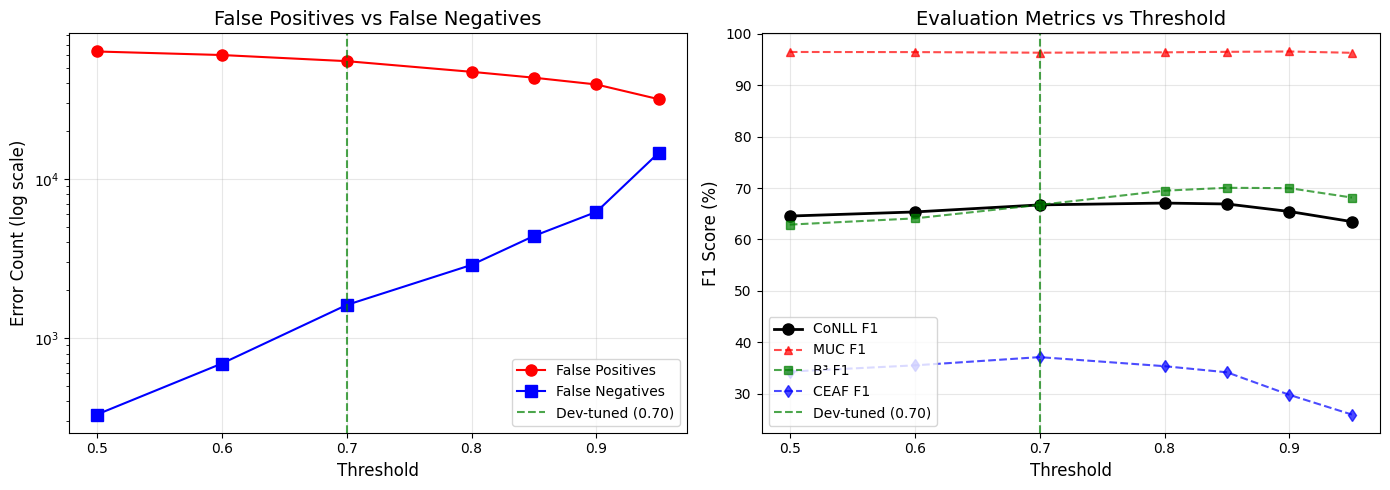


✓ Saved: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/error_analysis/threshold_analysis.png


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: FP vs FN
ax1 = axes[0]
thresholds = [r["threshold"] for r in threshold_results]
fps = [r["FP"] for r in threshold_results]
fns = [r["FN"] for r in threshold_results]

ax1.semilogy(thresholds, fps, "ro-", label="False Positives", markersize=8)
ax1.semilogy(thresholds, fns, "bs-", label="False Negatives", markersize=8)
ax1.axvline(x=BEST_THRESHOLD, color="green", linestyle="--", alpha=0.7, label=f"Dev-tuned ({BEST_THRESHOLD:.2f})")
ax1.set_xlabel("Threshold", fontsize=12)
ax1.set_ylabel("Error Count (log scale)", fontsize=12)
ax1.set_title("False Positives vs False Negatives", fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Metrics
ax2 = axes[1]
conll = [r["CoNLL_F1"] for r in threshold_results]
muc = [r["MUC_F1"] for r in threshold_results]
b3 = [r["B3_F1"] for r in threshold_results]
ceaf = [r["CEAF_F1"] for r in threshold_results]

ax2.plot(thresholds, conll, "ko-", label="CoNLL F1", markersize=8, linewidth=2)
ax2.plot(thresholds, muc, "r^--", label="MUC F1", markersize=6, alpha=0.7)
ax2.plot(thresholds, b3, "gs--", label="B³ F1", markersize=6, alpha=0.7)
ax2.plot(thresholds, ceaf, "bd--", label="CEAF F1", markersize=6, alpha=0.7)
ax2.axvline(x=BEST_THRESHOLD, color="green", linestyle="--", alpha=0.7, label=f"Dev-tuned ({BEST_THRESHOLD:.2f})")
ax2.set_xlabel("Threshold", fontsize=12)
ax2.set_ylabel("F1 Score (%)", fontsize=12)
ax2.set_title("Evaluation Metrics vs Threshold", fontsize=14)
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ERROR_OUTPUT_DIR / "threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.savefig(ERROR_OUTPUT_DIR / "threshold_analysis.pdf", bbox_inches="tight")
plt.show()

print(f"\n✓ Saved: {ERROR_OUTPUT_DIR / 'threshold_analysis.png'}")

## Cell 17: Threshold Analysis LaTeX Table

In [26]:
print("\n" + "=" * 70)
print("LATEX TABLE FOR THESIS")
print("=" * 70)

latex = r"""
\\begin{table}[htbp]
\\centering
\\caption{Threshold sensitivity analysis for MuRIL-Large. Lower thresholds increase false positives (over-linking); higher thresholds increase false negatives (under-linking).}
\\label{tab:threshold-analysis}
\\small
\\begin{tabular}{crrrccccc}
\\toprule
\\textbf{Threshold} & \\textbf{FP} & \\textbf{FN} & \\textbf{FP:FN} & \\textbf{CoNLL} & \\textbf{MUC} & \\textbf{B³} & \\textbf{CEAF} \\\\
\\midrule
"""

for r in threshold_results:
    ratio_str = f"{r['FP_FN_ratio']:.0f}:1" if r["FP_FN_ratio"] < 1000 else r"$\\infty$"
    fp_str = f"{r['FP']:,}"
    fn_str = f"{r['FN']:,}"
    
    if abs(r["threshold"] - BEST_THRESHOLD) < 0.01:
        latex += f"\\textbf{{{r['threshold']:.2f}}} & \\textbf{{{fp_str}}} & \\textbf{{{fn_str}}} & \\textbf{{{ratio_str}}} & \\textbf{{{r['CoNLL_F1']:.1f}}} & \\textbf{{{r['MUC_F1']:.1f}}} & \\textbf{{{r['B3_F1']:.1f}}} & \\textbf{{{r['CEAF_F1']:.1f}}} \\\\\n"
    else:
        latex += f"{r['threshold']:.2f} & {fp_str} & {fn_str} & {ratio_str} & {r['CoNLL_F1']:.1f} & {r['MUC_F1']:.1f} & {r['B3_F1']:.1f} & {r['CEAF_F1']:.1f} \\\\\n"

latex += r"""\\bottomrule
\\end{tabular}
\\end{table}
"""

print(latex)

# Save
with open(ERROR_OUTPUT_DIR / "threshold_table.tex", "w") as f:
    f.write(latex)
print(f"\n✓ Saved to: {ERROR_OUTPUT_DIR / 'threshold_table.tex'}")


LATEX TABLE FOR THESIS

\\begin{table}[htbp]
\\centering
\\caption{Threshold sensitivity analysis for MuRIL-Large. Lower thresholds increase false positives (over-linking); higher thresholds increase false negatives (under-linking).}
\\label{tab:threshold-analysis}
\\small
\\begin{tabular}{crrrccccc}
\\toprule
\\textbf{Threshold} & \\textbf{FP} & \\textbf{FN} & \\textbf{FP:FN} & \\textbf{CoNLL} & \\textbf{MUC} & \\textbf{B³} & \\textbf{CEAF} \\\\
\\midrule
0.50 & 63,375 & 331 & 191:1 & 64.6 & 96.5 & 62.9 & 34.3 \\
0.60 & 60,214 & 692 & 87:1 & 65.4 & 96.5 & 64.1 & 35.5 \\
\textbf{0.70} & \textbf{55,107} & \textbf{1,616} & \textbf{34:1} & \textbf{66.7} & \textbf{96.4} & \textbf{66.7} & \textbf{37.1} \\
0.80 & 47,225 & 2,887 & 16:1 & 67.1 & 96.4 & 69.5 & 35.3 \\
0.85 & 43,368 & 4,391 & 10:1 & 66.9 & 96.5 & 70.1 & 34.1 \\
0.90 & 39,317 & 6,221 & 6:1 & 65.4 & 96.6 & 70.0 & 29.7 \\
0.95 & 31,757 & 14,662 & 2:1 & 63.5 & 96.3 & 68.2 & 25.9 \\
\\bottomrule
\\end{tabular}
\\end{table}


✓ Saved

## Cell 18: Save All Results

In [27]:
# =============================================================================
# CONFUSION MATRIX: Calculate TP and TN
# =============================================================================

def calculate_confusion_matrix(model, test_docs, threshold):
    """Calculate full confusion matrix at mention-pair level."""
    model.pairwise_mlp.eval()
    
    total_tp = 0  # Correctly linked (both gold and pred say coref)
    total_tn = 0  # Correctly not linked (both say not coref)
    total_fp = 0  # Incorrectly linked (pred says coref, gold says no)
    total_fn = 0  # Incorrectly not linked (pred says no, gold says coref)
    
    for doc in tqdm(test_docs, desc="Computing confusion matrix"):
        n_mentions = len(doc["mentions"])
        if n_mentions < 2:
            continue
        
        # Get predictions
        embeddings = model.get_all_mention_embeddings(doc)
        scores = model.compute_pairwise_scores(embeddings)
        pred_clusters = graph_connected_components(scores, threshold)
        gold_clusters = doc["clusters"]
        
        # Build mappings: mention -> cluster_id
        gold_map = {}
        for c_idx, cluster in enumerate(gold_clusters):
            for m in cluster:
                gold_map[m] = c_idx
        
        pred_map = {}
        for c_idx, cluster in enumerate(pred_clusters):
            for m in cluster:
                pred_map[m] = c_idx
        
        # Check all mention pairs
        for i in range(n_mentions):
            for j in range(i + 1, n_mentions):
                gold_coref = (gold_map.get(i) == gold_map.get(j))
                pred_coref = (pred_map.get(i) == pred_map.get(j))
                
                if gold_coref and pred_coref:
                    total_tp += 1
                elif not gold_coref and not pred_coref:
                    total_tn += 1
                elif not gold_coref and pred_coref:
                    total_fp += 1
                else:  # gold_coref and not pred_coref
                    total_fn += 1
    
    return total_tp, total_tn, total_fp, total_fn

# Run it
print("=" * 70)
print("CALCULATING CONFUSION MATRIX")
print("=" * 70)
tp, tn, fp, fn = calculate_confusion_matrix(model, test_docs, BEST_THRESHOLD)

print("\n" + "=" * 70)
print("CONFUSION MATRIX (Mention-Pair Level)")
print("=" * 70)
print(f"\nThreshold: {BEST_THRESHOLD}")
print(f"\n                        Predicted")
print(f"                   Coref        Not Coref")
print(f"         Coref   {tp:>12,}   {fn:>12,}   | {tp+fn:,} gold coref pairs")
print(f"  Gold   Not     {fp:>12,}   {tn:>12,}   | {fp+tn:,} gold non-coref pairs")
print(f"         " + "─" * 42)
print(f"                 {tp+fp:>12,}   {fn+tn:>12,}   | {tp+tn+fp+fn:,} total pairs")

print(f"\n" + "=" * 70)
print("DERIVED METRICS")
print("=" * 70)
precision = tp / (tp + fp) * 100 if (tp + fp) > 0 else 0
recall = tp / (tp + fn) * 100 if (tp + fn) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision (TP / TP+FP): {precision:.2f}%")
print(f"Recall (TP / TP+FN):    {recall:.2f}%")
print(f"F1 Score:               {f1:.2f}%")
print(f"Accuracy:               {accuracy:.2f}%")
print(f"\nNote: High accuracy is expected due to class imbalance")
print(f"      (most mention pairs are not coreferent)")

CALCULATING CONFUSION MATRIX


Computing confusion matrix: 100%|██████████| 71/71 [18:45<00:00, 15.85s/it]


CONFUSION MATRIX (Mention-Pair Level)

Threshold: 0.7000000000000002

                        Predicted
                   Coref        Not Coref
         Coref         45,177          1,616   | 46,793 gold coref pairs
  Gold   Not           55,107         11,271   | 66,378 gold non-coref pairs
         ──────────────────────────────────────────
                      100,284         12,887   | 113,171 total pairs

DERIVED METRICS

Precision (TP / TP+FP): 45.05%
Recall (TP / TP+FN):    96.55%
F1 Score:               61.43%
Accuracy:               49.88%

Note: High accuracy is expected due to class imbalance
      (most mention pairs are not coreferent)


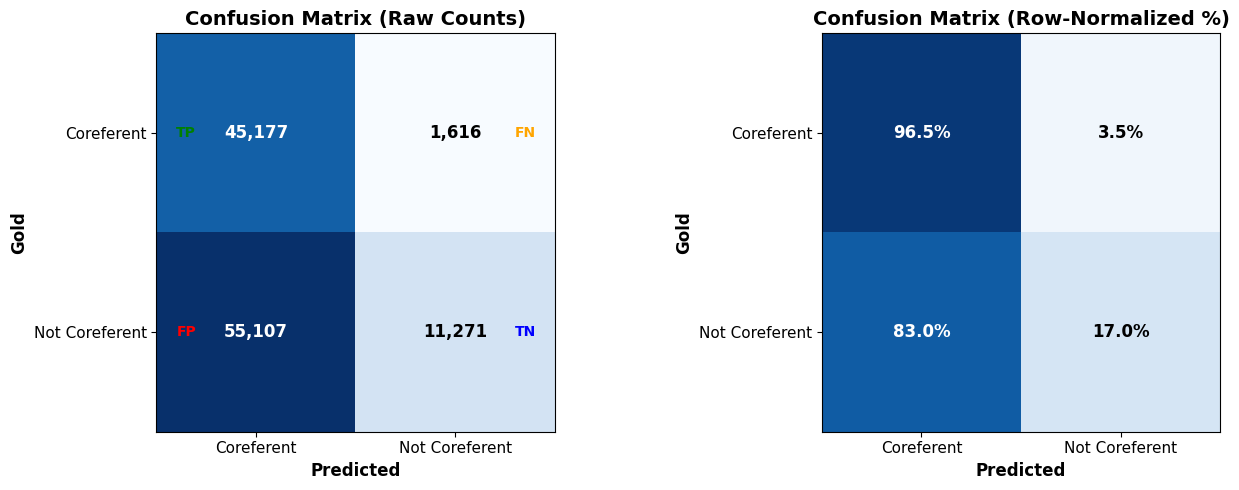


✓ Figure saved to: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/error_analysis/confusion_matrix.png


In [28]:
# =============================================================================
# CONFUSION MATRIX VISUALIZATION
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw counts (log scale for visibility)
ax1 = axes[0]
cm_raw = np.array([[tp, fn], [fp, tn]])
im1 = ax1.imshow(cm_raw, cmap='Blues')

# Add text annotations
for i in range(2):
    for j in range(2):
        val = cm_raw[i, j]
        # Format large numbers with commas
        text = f"{val:,}"
        color = "white" if val > cm_raw.max() / 2 else "black"
        ax1.text(j, i, text, ha="center", va="center", color=color, fontsize=12, fontweight='bold')

ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Coreferent', 'Not Coreferent'], fontsize=11)
ax1.set_yticklabels(['Coreferent', 'Not Coreferent'], fontsize=11)
ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax1.set_ylabel('Gold', fontsize=12, fontweight='bold')
ax1.set_title('Confusion Matrix (Raw Counts)', fontsize=14, fontweight='bold')

# Add labels in corners
ax1.text(-0.3, 0, 'TP', ha='right', va='center', fontsize=10, color='green', fontweight='bold')
ax1.text(1.3, 0, 'FN', ha='left', va='center', fontsize=10, color='orange', fontweight='bold')
ax1.text(-0.3, 1, 'FP', ha='right', va='center', fontsize=10, color='red', fontweight='bold')
ax1.text(1.3, 1, 'TN', ha='left', va='center', fontsize=10, color='blue', fontweight='bold')

# Right: Normalized by row (shows recall and specificity)
ax2 = axes[1]
cm_norm = np.array([
    [tp / (tp + fn) * 100 if (tp + fn) > 0 else 0, fn / (tp + fn) * 100 if (tp + fn) > 0 else 0],
    [fp / (fp + tn) * 100 if (fp + tn) > 0 else 0, tn / (fp + tn) * 100 if (fp + tn) > 0 else 0]
])
im2 = ax2.imshow(cm_norm, cmap='Blues', vmin=0, vmax=100)

for i in range(2):
    for j in range(2):
        val = cm_norm[i, j]
        text = f"{val:.1f}%"
        color = "white" if val > 50 else "black"
        ax2.text(j, i, text, ha="center", va="center", color=color, fontsize=12, fontweight='bold')

ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Coreferent', 'Not Coreferent'], fontsize=11)
ax2.set_yticklabels(['Coreferent', 'Not Coreferent'], fontsize=11)
ax2.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax2.set_ylabel('Gold', fontsize=12, fontweight='bold')
ax2.set_title('Confusion Matrix (Row-Normalized %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(ERROR_OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✓ Figure saved to: {ERROR_OUTPUT_DIR / 'confusion_matrix.png'}")

In [29]:
# =============================================================================
# LATEX TABLE FOR THESIS
# =============================================================================

print("\n" + "=" * 70)
print("LATEX CONFUSION MATRIX TABLE")
print("=" * 70)

latex_cm = f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Confusion matrix at mention-pair level (MuRIL-Large, Experiment 6, threshold={BEST_THRESHOLD}).}}
\\label{{tab:confusion-matrix}}
\\small
\\begin{{tabular}}{{ll|rr|r}}
\\toprule
& & \\multicolumn{{2}}{{c|}}{{\\textbf{{Predicted}}}} & \\\\
& & Coreferent & Not Coreferent & \\textbf{{Total}} \\\\
\\midrule
\\multirow{{2}}{{*}}{{\\textbf{{Gold}}}} & Coreferent & {tp:,} (TP) & {fn:,} (FN) & {tp+fn:,} \\\\
& Not Coreferent & {fp:,} (FP) & {tn:,} (TN) & {fp+tn:,} \\\\
\\midrule
& \\textbf{{Total}} & {tp+fp:,} & {fn+tn:,} & {tp+tn+fp+fn:,} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}

\\textbf{{Pair-level metrics:}} Precision = {precision:.1f}\\%, Recall = {recall:.1f}\\%, Accuracy = {accuracy:.1f}\\%
"""

print(latex_cm)

# Save
with open(ERROR_OUTPUT_DIR / "confusion_matrix_table.tex", "w") as f:
    f.write(latex_cm)
print(f"\n✓ Saved to: {ERROR_OUTPUT_DIR / 'confusion_matrix_table.tex'}")

# Also save the raw numbers to JSON
confusion_data = {
    "threshold": BEST_THRESHOLD,
    "true_positives": tp,
    "true_negatives": tn,
    "false_positives": fp,
    "false_negatives": fn,
    "total_pairs": tp + tn + fp + fn,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "accuracy": accuracy
}

with open(ERROR_OUTPUT_DIR / "confusion_matrix.json", "w") as f:
    json.dump(confusion_data, f, indent=2)
print(f"✓ Data saved to: {ERROR_OUTPUT_DIR / 'confusion_matrix.json'}")


LATEX CONFUSION MATRIX TABLE

\begin{table}[htbp]
\centering
\caption{Confusion matrix at mention-pair level (MuRIL-Large, Experiment 6, threshold=0.7000000000000002).}
\label{tab:confusion-matrix}
\small
\begin{tabular}{ll|rr|r}
\toprule
& & \multicolumn{2}{c|}{\textbf{Predicted}} & \\
& & Coreferent & Not Coreferent & \textbf{Total} \\
\midrule
\multirow{2}{*}{\textbf{Gold}} & Coreferent & 45,177 (TP) & 1,616 (FN) & 46,793 \\
& Not Coreferent & 55,107 (FP) & 11,271 (TN) & 66,378 \\
\midrule
& \textbf{Total} & 100,284 & 12,887 & 113,171 \\
\bottomrule
\end{tabular}
\end{table}

\textbf{Pair-level metrics:} Precision = 45.0\%, Recall = 96.5\%, Accuracy = 49.9\%


✓ Saved to: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/error_analysis/confusion_matrix_table.tex
✓ Data saved to: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/error_analysis/confusion_matrix.json


In [30]:
# Save threshold analysis results
all_analysis_results = {
    "model": "MuRIL-Large",
    "experiment": "exp6_bencoref_only",
    "current_threshold": BEST_THRESHOLD,
    "error_analysis": {
        "total_false_positives": total_fp,
        "total_false_negatives": total_fn,
        "by_category": {k: len(v) for k, v in categories.items()},
    },
    "threshold_analysis": threshold_results
}

with open(ERROR_OUTPUT_DIR / "complete_analysis.json", "w") as f:
    json.dump(all_analysis_results, f, indent=2, default=float)

print(f"✓ Complete results saved to: {ERROR_OUTPUT_DIR / 'complete_analysis.json'}")
print("\n" + "=" * 70)
print("ALL ANALYSIS COMPLETE")
print("=" * 70)

✓ Complete results saved to: /teamspace/studios/this_studio/final_experiments/experiment_6_bencoref_only/error_analysis/complete_analysis.json

ALL ANALYSIS COMPLETE
